#📌 Extracción

In [164]:
import pandas as pd

In [165]:
df = pd.read_json("TelecomX_Data.json")
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [166]:
df_customer = pd.json_normalize(df["customer"])
df_phone    = pd.json_normalize(df["phone"])
df_internet = pd.json_normalize(df["internet"])
df_account  = pd.json_normalize(df["account"])

In [167]:
df_normalizado = pd.concat(
    [
        df[["customerID", "Churn"]],
        df_customer,
        df_phone,
        df_internet,
        df_account
    ],
    axis=1
)
df_normalizado

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

In [168]:
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [169]:
#encontrando valores duplicados
df_normalizado[df_normalizado['customerID'].duplicated(keep=False)]

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total


Verificando valores booleanos

In [170]:
columnas_interes = df_normalizado.columns[1:19].delete(5)
columnas_interes

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [171]:
# sacando los valores distintos
valores_distintos = {
    col: df_normalizado[col].drop_duplicates().sort_values().reset_index(drop=True)
    for col in columnas_interes
}
valores_distintos

{'Churn': 0       
 1     No
 2    Yes
 Name: Churn, dtype: object,
 'gender': 0    Female
 1      Male
 Name: gender, dtype: object,
 'SeniorCitizen': 0    0
 1    1
 Name: SeniorCitizen, dtype: int64,
 'Partner': 0     No
 1    Yes
 Name: Partner, dtype: object,
 'Dependents': 0     No
 1    Yes
 Name: Dependents, dtype: object,
 'PhoneService': 0     No
 1    Yes
 Name: PhoneService, dtype: object,
 'MultipleLines': 0                  No
 1    No phone service
 2                 Yes
 Name: MultipleLines, dtype: object,
 'InternetService': 0            DSL
 1    Fiber optic
 2             No
 Name: InternetService, dtype: object,
 'OnlineSecurity': 0                     No
 1    No internet service
 2                    Yes
 Name: OnlineSecurity, dtype: object,
 'OnlineBackup': 0                     No
 1    No internet service
 2                    Yes
 Name: OnlineBackup, dtype: object,
 'DeviceProtection': 0                     No
 1    No internet service
 2                    Ye

In [172]:
tabla_valores_distintos = (
    df_normalizado[columnas_interes]
    .melt(var_name="columna", value_name="valor")
    .drop_duplicates()
    .sort_values(["columna", "valor"])
    .reset_index(drop=True)
)
tabla_valores_distintos

,columna,valor
0,Churn,
1,Churn,No
2,Churn,Yes
3,Contract,Month-to-month
4,Contract,One year
5,Contract,Two year
6,Dependents,No
7,Dependents,Yes
8,DeviceProtection,No
9,DeviceProtection,No internet service


In [173]:
valores_distintos["Churn"]


,Churn
0,
1,No
2,Yes


In [174]:
valores_distintos["DeviceProtection"]


,DeviceProtection
0,No
1,No internet service
2,Yes


In [175]:
valores_distintos["MultipleLines"]


,MultipleLines
0,No
1,No phone service
2,Yes


In [176]:
valores_distintos["OnlineBackup"]


,OnlineBackup
0,No
1,No internet service
2,Yes


In [177]:
valores_distintos["OnlineSecurity"]


,OnlineSecurity
0,No
1,No internet service
2,Yes


In [178]:
valores_distintos["StreamingMovies"]


,StreamingMovies
0,No
1,No internet service
2,Yes


In [179]:
valores_distintos["StreamingTV"]


,StreamingTV
0,No
1,No internet service
2,Yes


In [180]:
valores_distintos["TechSupport"]


,TechSupport
0,No
1,No internet service
2,Yes


Manejo de inconsistencias

In [181]:
# Reemplazando valores

columnas_objetivo = ["DeviceProtection", "MultipleLines", "OnlineBackup", "OnlineSecurity", "StreamingMovies", "StreamingTV", "TechSupport"]

In [182]:
# Reemplazando valores
df_normalizado[columnas_objetivo] = df_normalizado[columnas_objetivo].replace(
    {
        r'(?i).*no.*': 'No'
    },
    regex=True
)

In [183]:
#verificando

df_normalizado["TechSupport"].unique()

array(['Yes', 'No'], dtype=object)

In [184]:
#verificando

df_normalizado["MultipleLines"].unique()

array(['No', 'Yes'], dtype=object)

In [185]:
#Evaluando el dato vacio de churn

delete = (df_normalizado['Churn'].isna() | (df_normalizado['Churn'].str.strip() == '')).sum()
delete

np.int64(224)

In [186]:
df_normalizado = df_normalizado.dropna(subset=['Churn'])
df_normalizado = df_normalizado[df_normalizado['Churn'] != '']

In [187]:
# VERIFICANDO VALORES UNICOS DE CHURN

df_normalizado['Churn'].unique()

array(['No', 'Yes'], dtype=object)

Estandarización y transformación de datos (opcional)

In [188]:
mapa_01 = {
    'Yes': 1, 'No': 0,
    'True': 1, 'False': 0,
    True: 1, False: 0,
    1: 1, 0: 0,
    '1': 1, '0': 0
}

In [189]:
# columnas boleanas

columnas_binarias = ['Churn', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines',  'SeniorCitizen','OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling'

]

In [243]:
#convirtiendo columna por columna en 0 y 1
for col in columnas_binarias:
    df_normalizado['SeniorCitizen'] = df_normalizado['StreamingMovies'].replace(mapa_01).astype(int)

In [242]:
df_normalizado['SeniorCitizen'].unique()

array([0, 1])

#📊 Carga y análisis

In [249]:
df_normalizado[['PaperlessBilling', 'Charges.Monthly']].describe()

,PaperlessBilling,Charges.Monthly
count,7043.000000,7043.000000
mean,0.592219,64.761692
std,0.491457,30.090047
min,0.000000,18.250000
25%,0.000000,35.500000
50%,1.000000,70.350000
75%,1.000000,89.850000
max,1.000000,118.750000


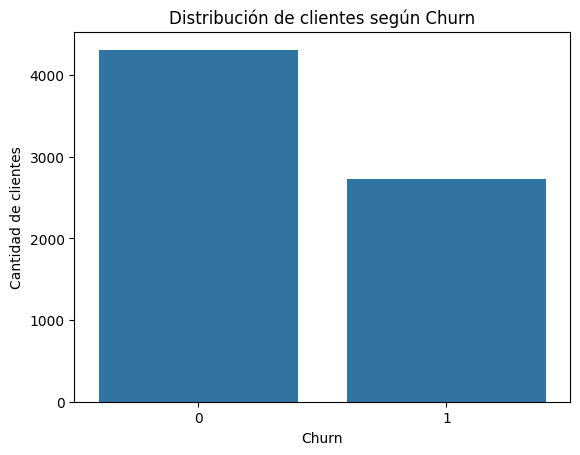

In [250]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Churn", data=df_normalizado)
plt.title("Distribución de clientes según Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.show()

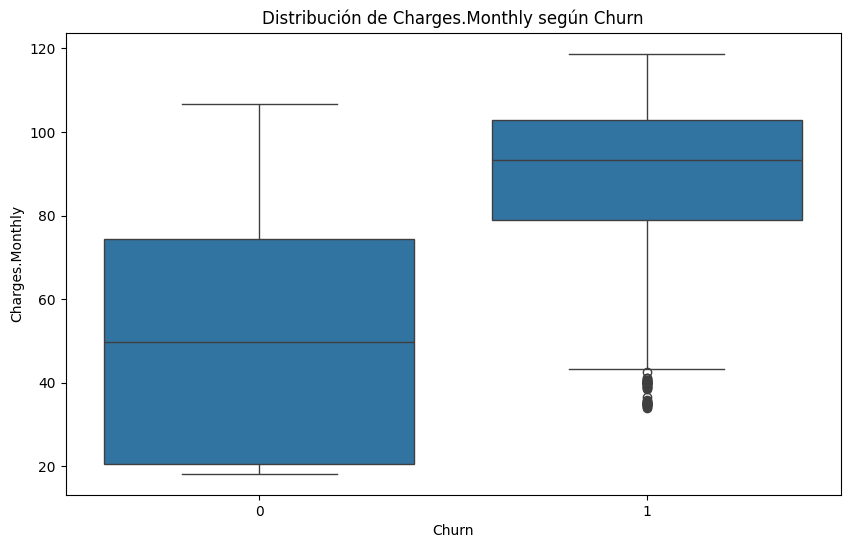

In [254]:
# grafico boxplot


plt.figure(figsize=(10, 6))
sns.boxplot(x="Churn", y="Charges.Monthly", data=df_normalizado)
plt.xlabel("Churn")
plt.ylabel("Charges.Monthly")
plt.title("Distribución de Charges.Monthly según Churn")
plt.show()

Recuento de evasión por variables categóricas

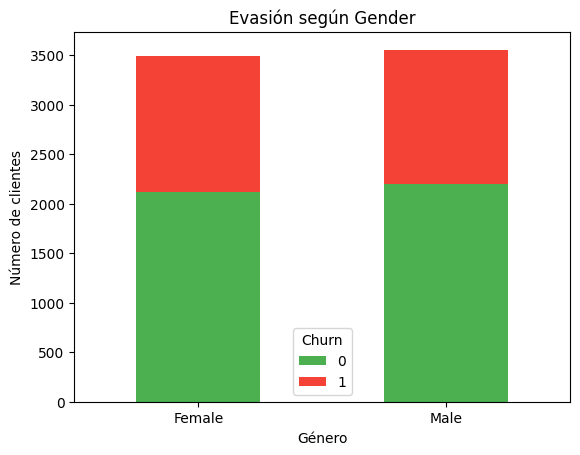

In [257]:
counts = pd.crosstab(df_normalizado['gender'], df_normalizado['Churn'])
counts.plot(kind='bar', stacked=True, color=['#4CAF50','#F44336'])
plt.title("Evasión según Gender")
plt.xlabel("Género")
plt.ylabel("Número de clientes")
plt.xticks(rotation=0)
plt.show()

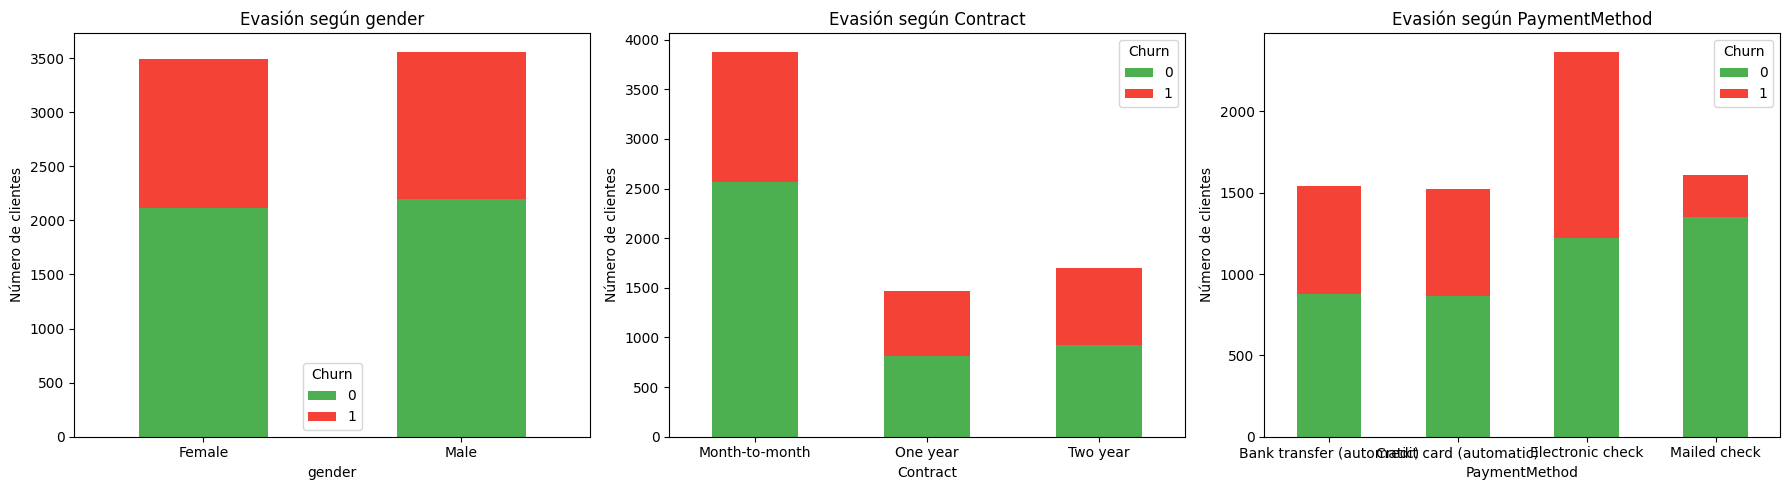

In [259]:
variables_categoricas = ['gender', 'Contract', 'PaymentMethod']

# Definir la cantidad de filas y columnas según el número de variables
fig, axes = plt.subplots(1, len(variables_categoricas), figsize=(18,5))  # 1 fila, N columnas

for i, var in enumerate(variables_categoricas):
    counts = pd.crosstab(df_normalizado[var], df_normalizado['Churn'])

    # Graficar en el subplot correspondiente
    counts.plot(kind='bar', stacked=True, color=['#4CAF50','#F44336'], ax=axes[i])
    axes[i].set_title(f"Evasión según {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Número de clientes")
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Churn')

plt.tight_layout()
plt.show()

In [264]:
#variables numericas

numerical_vars = ["Dependents", "tenure","PhoneService","Charges.Total","MultipleLines","StreamingTV","StreamingMovies","Charges.Monthly"]

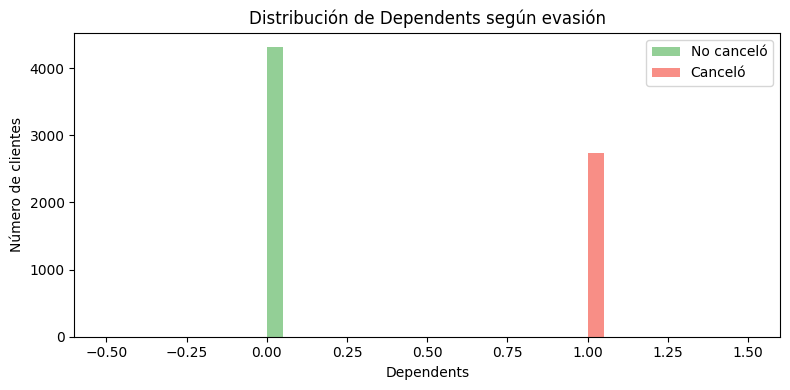

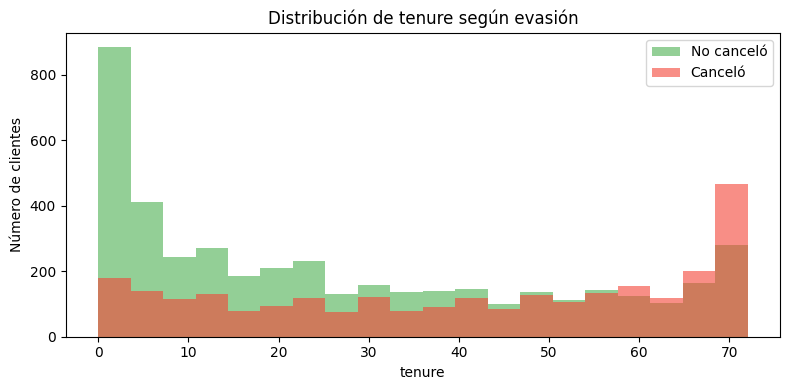

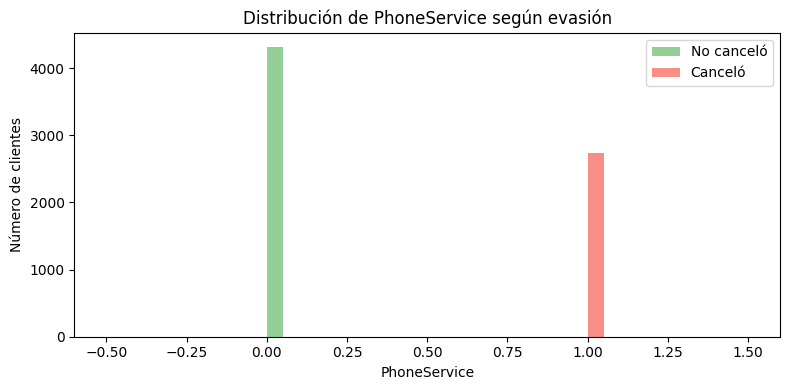

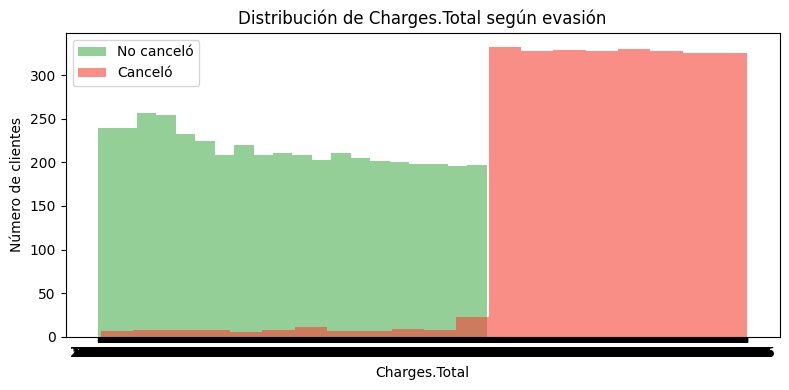

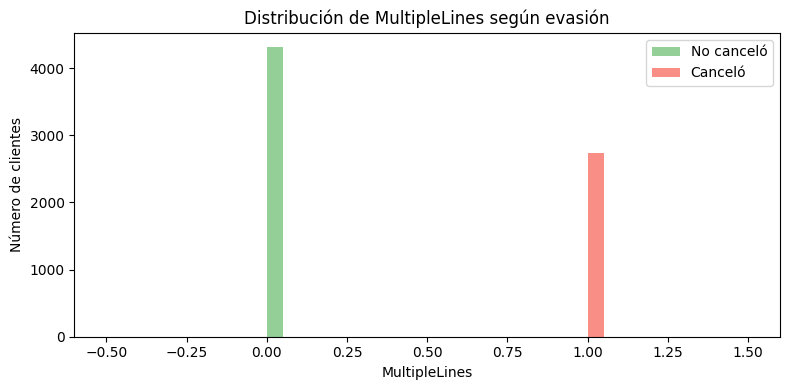

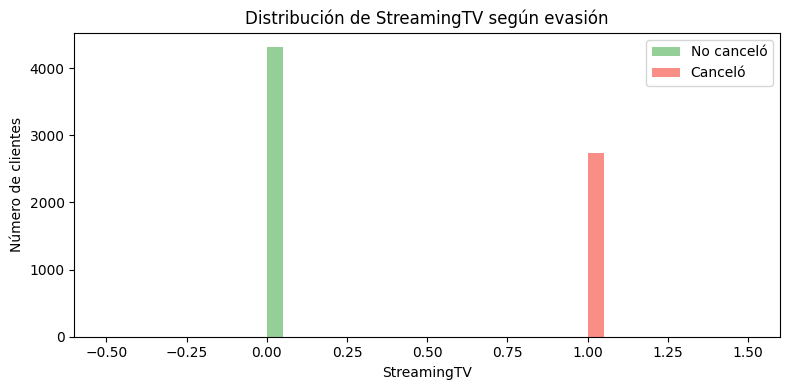

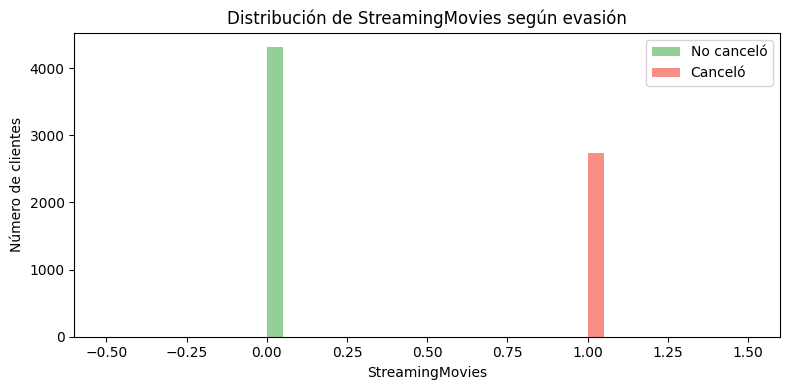

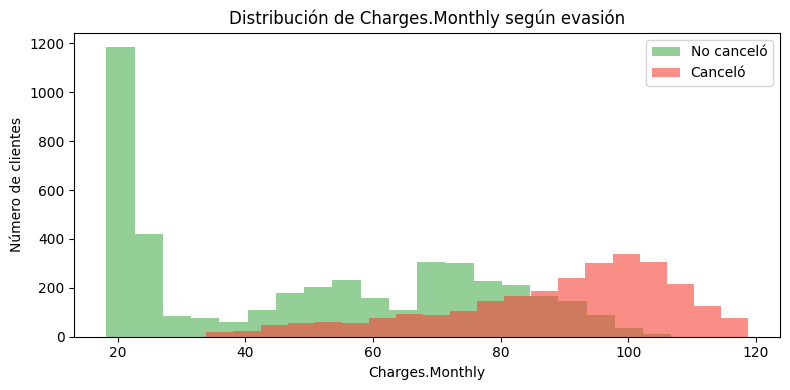

In [265]:
for var in numerical_vars:
    plt.figure(figsize=(8,4))

    stayed = df_normalizado[df_normalizado['Churn'] == 0][var]
    left = df_normalizado[df_normalizado['Churn'] == 1][var]

    # Histograma comparativo
    plt.hist(stayed, bins=20, alpha=0.6, label='No canceló', color='#4CAF50')
    plt.hist(left, bins=20, alpha=0.6, label='Canceló', color='#F44336')

    plt.title(f"Distribución de {var} según evasión")
    plt.xlabel(var)
    plt.ylabel("Número de clientes")
    plt.legend()
    plt.tight_layout()
    plt.show()



#📄Informe final

**Introducción**
Telecom X enfrenta una alta tasa de cancelación de clientes (churn), lo que impacta sus ingresos y fidelidad. Como parte del proyecto “Churn de Clientes”, he realizado un análisis de datos utilizando Python para identificar patrones y factores que influyen en la evasión.




**Limpieza y Tratamiento de Datos**

Para el análisis se utilizó un archivo en formato **JSON**, que fue cargado en **Google Colab** y convertido en un **DataFrame** de Pandas.  
Las columnas anidadas se aplanaron utilizando `json_normalize` para facilitar su manipulación.  

A continuación, se revisó la estructura del DataFrame mediante `info()` para entender los tipos de datos y la integridad de los registros.  
Se verificaron **duplicados**, encontrando que no existían, y se evaluaron **valores nulos o vacíos**, identificando 224 registros nulos en el campo **Churn**, los cuales fueron eliminados.  

Varios campos estaban en formato **booleano**, pero algunos contenían valores distintos a 0, 1, “Yes” o “No”. Entre estos se encuentran:  

- `DeviceProtection`  
- `MultipleLines`  
- `OnlineBackup`  
- `OnlineSecurity`  
- `StreamingMovies`  
- `StreamingTV`  
- `TechSupport`  

Estos campos fueron normalizados y convertidos a valores **0 y 1** para asegurar consistencia y compatibilidad en los análisis posteriores.

**Análisis Exploratorio de Datos**

Se realizó un **análisis descriptivo** de los campos `'PaperlessBilling'` y `'Charges.Monthly'` utilizando `describe()`, lo que permitió observar la **media, mediana y suma**, entre otras estadísticas descriptivas.  

Para visualizar la distribución de la evasión de clientes, se creó un **countplot** mostrando la cantidad de usuarios que cancelaron sus servicios.  

Además, se generaron **gráficos de barras** para explorar la distribución de variables categóricas como:  
- `gender`  
- `Contract`  
- `PaymentMethod`  

De manera similar, se analizaron las variables numéricas mediante gráficos, incluyendo:  
- `Dependents`  
- `tenure`  
- `PhoneService`  

Este análisis permitió identificar patrones iniciales en los datos y comprender mejor el comportamiento de los clientes en Telecom X.

**Conclusiones e Insights**

Género (`Gender`)
- Hombres y mujeres presentan prácticamente la **misma proporción** de clientes que se van (Churn = 1) y los que se quedan (Churn = 0).  
- Esto indica que el género **no parece ser un factor determinante** en la evasión de clientes.

Tipo de contrato (`Contract`)
- Los clientes con **contrato mes a mes (Month-to-month)** presentan claramente **más evasión** que los clientes con contratos anuales o de 2 años.  
- Esto sugiere que los clientes con contratos cortos son **más propensos a cancelar**, un insight clave para diseñar estrategias de retención.

Método de pago (`PaymentMethod`)
- La evasión es **más alta en clientes que utilizan Electronic check**, y algo menor en los que usan **Credit card** o **Bank transfer**.  
- Esto podría indicar que ciertos métodos de pago están asociados con un mayor riesgo de abandono y merece un análisis adicional.

**Otros insights importantes**
- Dependientes: Los clientes sin dependientes presentan mayor probabilidad de no cancelar.  
- Servicio telefónico (`PhoneService`):Tener servicio telefónico reduce la probabilidad de cancelar.  
- Gasto mensual (`Charges.Monthly`):A mayor gasto, mayor es la probabilidad de cancelar.  
- Número de líneas telefónicas (`MultipleLines`): Mientras más líneas tienen, menor es la probabilidad de cancelar.  
- Servicios de streaming (`StreamingTV` / `StreamingMovies`): Los clientes con servicios de streaming tienden a no cancelar**.  

Estos insights permiten identificar patrones de comportamiento de los clientes y apoyar la creación de estrategias de retención más efectivas en Telecom X.

**Recomendaciones Estratégicas**

Basándonos en el análisis de evasión de clientes, se sugieren las siguientes acciones estratégicas para **Telecom X**:  

1. Focalizar retención en contratos mes a mes:
   - Los clientes con contratos cortos presentan mayor probabilidad de cancelar.  
   - Se recomienda ofrecer incentivos, descuentos o beneficios adicionales para fomentar la renovación o transición a contratos de mayor duración.

2. Revisar métodos de pago de alto riesgo:
   - Los clientes que utilizan **Electronic check** muestran mayor evasión.  
   - Considerar campañas de educación sobre métodos de pago seguros o incentivar el uso de otros métodos menos propensos a abandono.

3. Promover servicios adicionales:
   - Clientes con servicios como **PhoneService** o **Streaming** tienden a mantenerse.  
   - Ofrecer paquetes combinados que incluyan estos servicios puede aumentar la fidelidad y reducir la cancelación.

4. Segmentación según gasto y dependientes:
   - Los clientes con mayor gasto mensual tienen mayor probabilidad de cancelar, mientras que los que tienen dependientes tienden a quedarse.  
   - Diseñar estrategias diferenciadas según perfil de cliente, como planes personalizados o programas de fidelización.

5. Monitoreo continuo de indicadores clave:
   - Establecer dashboards que permitan identificar **patrones de churn** en tiempo real y reaccionar rápidamente a posibles riesgos de abandono.

Estas recomendaciones permiten **apoyar decisiones basadas en datos** y orientar estrategias de retención para disminuir la evasión de clientes en Telecom X.